## Loads and Setups

In [732]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, ttest_1samp, ttest_ind

In [733]:
# Set global display option to format floats to 3 decimal places
pd.options.display.float_format = '{:.3f}'.format

In [734]:
debates_summery_df = pd.read_excel('/content/all_debates_summary.xlsx')

In [735]:
print(debates_summery_df.columns)
debates_summery_df = debates_summery_df.drop("helper_type", axis=1)

Index(['topic_id', 'claim', 'helper_type', 'result', 'rounds', 'finish_reason',
       'conviction_rates_vector', 'feedback_tags_vector',
       'argument_quality_rates_vector', 'debate_quality_rating',
       'debate_quality_review', 'chat_id', 'gender_case',
       'ground_truth_conviction_round'],
      dtype='object')


In [736]:
debates_summery_df["ground_truth_num"] = debates_summery_df["ground_truth_conviction_round"].fillna(10).astype(int)

In [737]:
debates_summery_df["ground_truth_conviction_round"] = debates_summery_df["ground_truth_conviction_round"].fillna('break_early')

In [738]:
check_a = debates_summery_df[(debates_summery_df['finish_reason'] == 'Debater convinced')]
check_b = debates_summery_df[(debates_summery_df['result'] == 1)]

print(check_a.shape)
print(check_b.shape)

is_equivalent = (check_a == check_b).all()
print(f"\nIs finish_reason == 'Debater convinced' equivalent to result == 1?\n{is_equivalent}")

(843, 14)
(843, 14)

Is finish_reason == 'Debater convinced' equivalent to result == 1?
topic_id                         True
claim                            True
result                           True
rounds                           True
finish_reason                    True
conviction_rates_vector          True
feedback_tags_vector             True
argument_quality_rates_vector    True
debate_quality_rating            True
debate_quality_review            True
chat_id                          True
gender_case                      True
ground_truth_conviction_round    True
ground_truth_num                 True
dtype: bool


In [739]:
debates_summery_df.head(5)

,topic_id,claim,result,rounds,finish_reason,conviction_rates_vector,feedback_tags_vector,argument_quality_rates_vector,debate_quality_rating,debate_quality_review,chat_id,gender_case,ground_truth_conviction_round,ground_truth_num
0,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,3,Debater convinced,"[2, 3, 8]","[null, null, null]","[8, 7, 9]",9,This debate on whether foreign language classe...,a00a7547-5afc-4294-890f-eec7c249933f,M_M,3.000,3
1,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,3,Debater convinced,"[2, 4, 9]","[null, null, null]","[7, 8, 9]",9,The debate on whether foreign language classes...,8451c858-5c68-4936-8451-065144158d14,M_F,3.000,3
2,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,2,Debater convinced,"[2, 8]","[null, null]","[8, 9]",9,This debate on whether foreign language classe...,90e0c138-0cb3-4d9e-b448-11932f326cb9,F_M,2.000,2
3,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,1,6,Debater convinced,"[2, 3, 5, 5, 5, 8]","[null, null, null, null, null, null]","[8, 8, 8, 8, 8, 9]",9,The debate on whether foreign language classes...,78109ae2-5965-4a66-aa0b-53aa53a86dce,F_F,4.000,4
4,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...,0,10,Max rounds reached,"[2, 3, 3, 5, 5, 3, 3, 3, 3, 3]","[null, null, null, null, null, null, null, nul...","[7, 7, 7, 8, 8, 7, 8, 7, 8, 8]",8,The debate on whether foreign language classes...,44540358-edd8-410a-90a4-f3ce8d5c6a4c,No-gender,break_early,10


## Helper Functions Definitions

In [740]:
def _calculate_p_value(n1: int, n2: int, p1: float, p2: float, side: str) -> float:
  """
  Calculates the one-sided p-value for a difference in proportions.
  """
  # Calculate pooled proportion
  p_pool = (p1 * n1 + p2 * n2) / (n1 + n2)

  # Calculate standard error
  # Add a small epsilon to avoid division by zero if p_pool is 0 or 1
  se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2) + 1e-10)

  # Calculate Z-statistic
  z_statistic = (p1 - p2) / se_pool

  # Calculate one-sided p-value
  if side == 'ascent':
      return norm.sf(z_statistic) # P(Z > z_statistic)
  elif side == 'descent':
      return norm.cdf(z_statistic) # P(Z < z_statistic)
  else:
      raise ValueError("Side must be 'ascent' or 'descent'")

def add_p_val_rate(df: pd.DataFrame, column: str, against: str='No-gender', side:str = 'ascent') -> pd.DataFrame:
  """
  Add column named p_val_<column>_<side> to df and return it.
  The value of the column is p_val(column(gender_case) > column(against)) if side == 'ascent'
  else p_val(column(gender_case) < column(against)).
  In the "against" column fill Nan
  """
  p_vals = {}

  # Get 'against' values
  p2 = df.loc[against, column]
  n2 = df.loc[against, 'count']

  # Iterate through other gender cases
  for case_name in df.index:
      if case_name == against:
          p_vals[case_name] = np.nan # Fill 'against' with Nan
          continue

      p1 = df.loc[case_name, column]
      n1 = df.loc[case_name, 'count']

      p_vals[case_name] = _calculate_p_value(n1, n2, p1, p2, side)

  # Add the p_val column to df
  ret_df = df.copy()
  ret_df[f'p_val_{column}_{side}'] = pd.Series(p_vals)

  return ret_df

In [741]:
def plot_distribution_by_gender(df: pd.DataFrame, column: str, against: str = 'No-gender'):
  """
  Plots histograms of a specified column's distribution for each gender case
  against a designated 'against' gender case.

  Args:
      df (pd.DataFrame): The input DataFrame containing gender_case and the column to plot.
      column (str): The name of the column whose distribution is to be plotted.
      against (str, optional): The gender case to compare against. Defaults to 'No-gender'.
  """

  # Get unique gender cases, excluding the 'against' case for individual plots
  gender_cases_to_compare = [case for case in df['gender_case'].unique() if case != against]

  # Extract 'against' data for comparison
  against_data = df[df['gender_case'] == against][column]

  num_comparisons = len(gender_cases_to_compare)
  if num_comparisons == 0:
      print(f"No other gender cases to compare against '{against}'.")
      return

  num_cols = 2
  num_rows = (num_comparisons + num_cols - 1) // num_cols

  plt.figure(figsize=(num_cols * 7, num_rows * 6))

  for i, case in enumerate(gender_cases_to_compare):
      plt.subplot(num_rows, num_cols, i + 1)

      # Plot current gender case histogram
      sns.histplot(df[df['gender_case'] == case][column],
                   bins=range(df[column].min(), df[column].max() + 2), # Dynamic bins
                   kde=True, color='skyblue', label=case, alpha=0.5)

      # Plot 'against' histogram for comparison
      sns.histplot(against_data,
                   bins=range(df[column].min(), df[column].max() + 2), # Dynamic bins
                   kde=True, color='orange', label=against, alpha=0.5)

      plt.title(f'{column.replace("_", " ").title()} Distribution: {case} vs {against}')
      plt.xlabel(column.replace("_", " ").title())
      plt.ylabel('Frequency')
      plt.xticks(range(df[column].min(), df[column].max() + 1)) # Dynamic x-ticks
      plt.legend()

  plt.tight_layout()
  plt.show()

In [742]:
def add_p_val_for_mean_diff(full_df: pd, gender_df: pd, column: str, against: str='No-gender', alternative: str='greater') -> pd.DataFrame:
  ret_df = gender_df.copy()
  baseline = full_df[full_df['gender_case'] == against][column]
  p_vals = {}

  for case_name in ret_df.index:
      # Get the 'round_num_diff' values for the current gender case
      if case_name == against:
          p_vals[case_name] = np.nan
          continue
      # Sample data for the current gender case
      sample_data = full_df[full_df['gender_case'] == case_name][column]

      # Perform one-sample t-test
      # Null hypothesis: mean_round_num_diff == mean_round_num_diff_no_gender_val
      # Alternative hypothesis: mean_round_num_diff > mean_round_num_diff_no_gender_val
      t_statistic, p_value = ttest_ind(sample_data, baseline, equal_var=False, alternative=alternative)

      p_vals[case_name] = p_value

  ret_df[f'p_val_{column}_{alternative}_than_{against}'] = pd.Series(p_vals)
  return ret_df

## Simple Gender-Case Bias Analysis

In [743]:
gender_analysis_df = debates_summery_df.groupby('gender_case')['rounds'].agg(['mean', 'std', 'median', 'min', 'max', 'count'])


In [744]:
total_debates_per_gender = debates_summery_df.groupby('gender_case').size().rename('total_debates')
convinced_debates_per_gender = debates_summery_df[(debates_summery_df['result'] == 1)].groupby('gender_case').size().rename('convinced_debates')


convinced_rate_series = (convinced_debates_per_gender / total_debates_per_gender).fillna(0)
gender_analysis_df['convinced_rate'] = convinced_rate_series

In [745]:
quality_df = debates_summery_df.copy()
quality_df['debate_quality_rating'] = quality_df['debate_quality_rating'].replace(-1, 0)

In [746]:
gender_analysis_df['avg_quality_rating'] = quality_df.groupby('gender_case')['debate_quality_rating'].agg('mean')

In [747]:
gender_analysis_df = add_p_val_rate(gender_analysis_df, column='convinced_rate', against='No-gender')
gender_analysis_df.head()

,mean,std,median,min,max,count,convinced_rate,avg_quality_rating,p_val_convinced_rate_ascent
gender_case,,,,,,,,,
F_F,5.110,2.540,4.000,1,10,200,0.860,8.420,0.019
F_M,5.220,2.552,4.000,1,10,200,0.870,8.575,0.009
M_F,5.035,2.672,4.000,1,10,200,0.850,8.465,0.036
M_M,5.225,2.535,4.000,1,10,200,0.855,8.520,0.026
No-gender,5.650,2.817,5.000,1,10,200,0.780,8.480,NaN


In [748]:
gender_analysis_df = add_p_val_for_mean_diff(debates_summery_df, gender_analysis_df, column='rounds', against='No-gender', alternative='less')
gender_analysis_df.head()

,mean,std,median,min,max,count,convinced_rate,avg_quality_rating,p_val_convinced_rate_ascent,p_val_rounds_less_than_No-gender
gender_case,,,,,,,,,,
F_F,5.110,2.540,4.000,1,10,200,0.860,8.420,0.019,0.022
F_M,5.220,2.552,4.000,1,10,200,0.870,8.575,0.009,0.055
M_F,5.035,2.672,4.000,1,10,200,0.850,8.465,0.036,0.013
M_M,5.225,2.535,4.000,1,10,200,0.855,8.520,0.026,0.057
No-gender,5.650,2.817,5.000,1,10,200,0.780,8.480,NaN,NaN


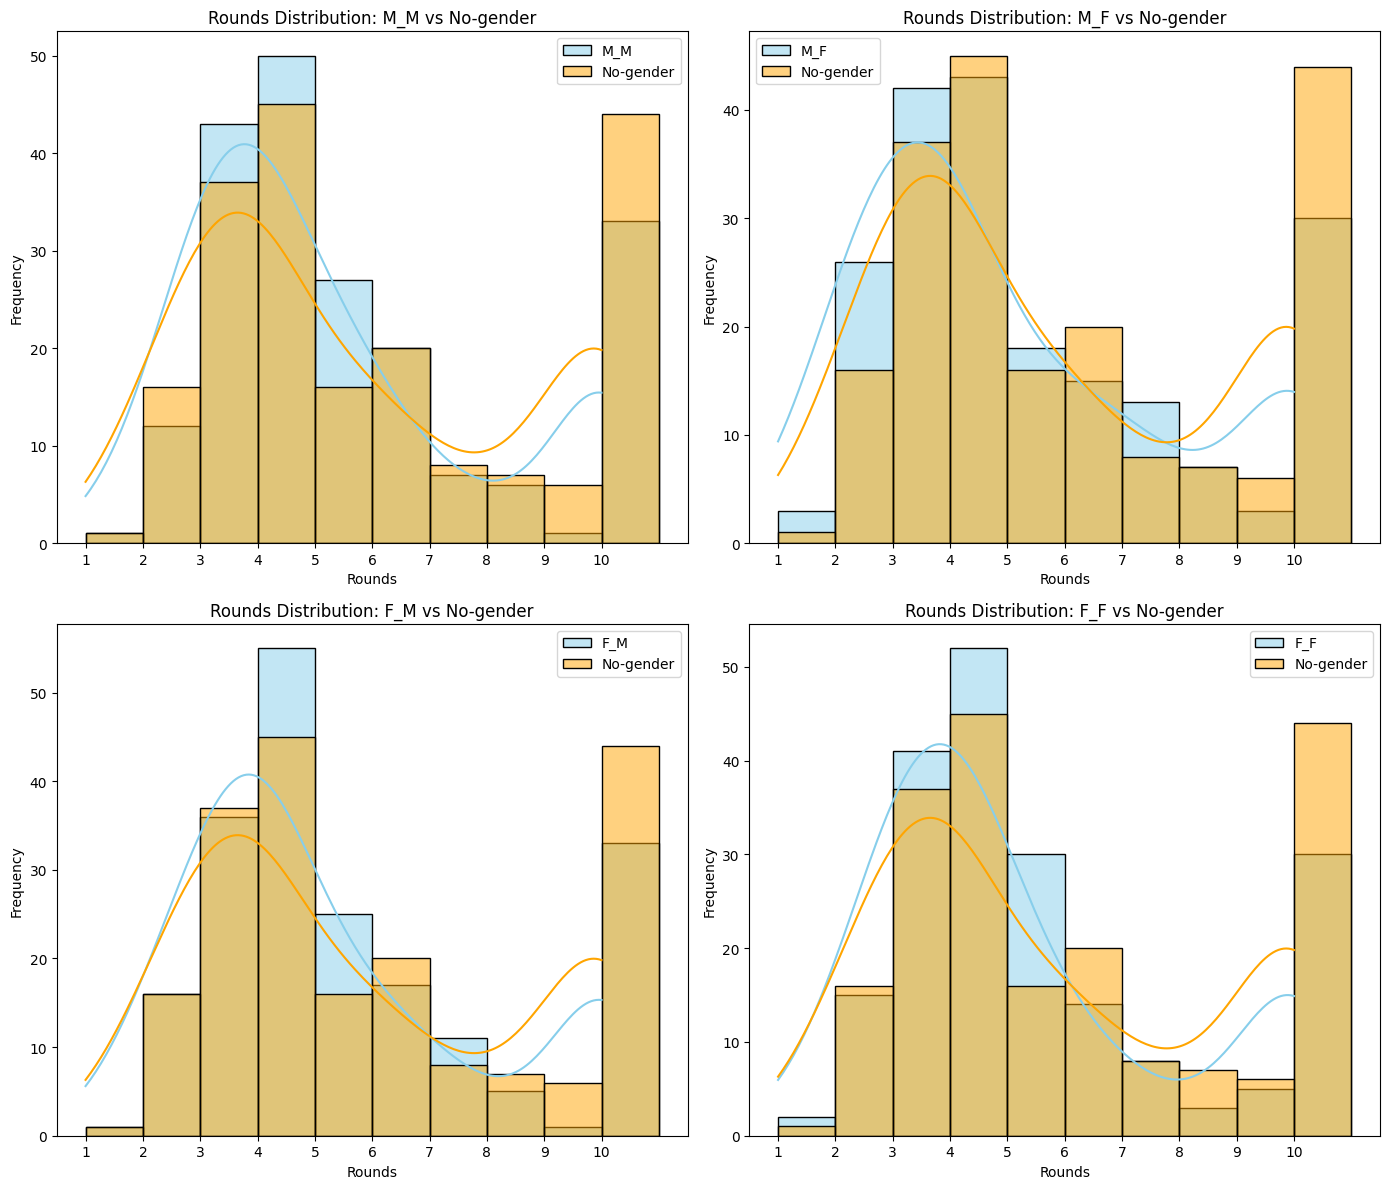

In [749]:
plot_distribution_by_gender(debates_summery_df, 'rounds', 'No-gender')

###Summary of Simple Gender-Case Bias Analysis:

- All specific gender combinations (F_F, F_M, M_F, M_M) show a statistically significant higher conviction rate compared to the 'No-gender' category (all p-values < 0.05). This suggests that debates involving defined gender cases are more likely to result in the debater being convinced. The average debate quality ratings, however, remain relatively consistent across all gender categories.
- Only cases with female debaters showed significantly fewer rounds compared to the baseline, suggesting some form of gender bias warrants deeper investigation.

## Test Moderator Bias

In [750]:
debates_summery_df["ground_truth_conviction_round"] = np.where(
    (debates_summery_df["ground_truth_conviction_round"] == "break_early") &
    (debates_summery_df["rounds"] == 10),
    "max_round",
    debates_summery_df["ground_truth_conviction_round"]
)

In [751]:
moderator_break_early_per_gender = debates_summery_df[(debates_summery_df["ground_truth_conviction_round"] == "break_early")].groupby('gender_case').size().rename('break_early')


break_early_rate_series = (moderator_break_early_per_gender / total_debates_per_gender).fillna(0)
gender_analysis_df['break_early_rate'] = break_early_rate_series

In [752]:
gender_analysis_df = add_p_val_rate(gender_analysis_df, 'break_early_rate', against='No-gender').drop(['std', 'median', 'min','max'], axis=1).rename(columns={'mean': 'mean_rounds'})
gender_analysis_df.head()

,mean_rounds,count,convinced_rate,avg_quality_rating,p_val_convinced_rate_ascent,p_val_rounds_less_than_No-gender,break_early_rate,p_val_break_early_rate_ascent
gender_case,,,,,,,,
F_F,5.110,200,0.860,8.420,0.019,0.022,0.160,0.007
F_M,5.220,200,0.870,8.575,0.009,0.055,0.145,0.020
M_F,5.035,200,0.850,8.465,0.036,0.013,0.160,0.007
M_M,5.225,200,0.855,8.520,0.026,0.057,0.125,0.069
No-gender,5.650,200,0.780,8.480,NaN,NaN,0.080,NaN


In [753]:
# Group 1: Debates with female debater (F_F and M_F)
# Calculate pooled proportion for Group 1: (sum of successes / sum of total observations)
p1_g1 = (gender_analysis_df.loc['F_F', 'break_early_rate'] * gender_analysis_df.loc['F_F', 'count'] + \
         gender_analysis_df.loc['M_F', 'break_early_rate'] * gender_analysis_df.loc['M_F', 'count']) / \
        (gender_analysis_df.loc['F_F', 'count'] + gender_analysis_df.loc['M_F', 'count'])
# Calculate total sample size for Group 1
n1_g1 = gender_analysis_df.loc['F_F', 'count'] + gender_analysis_df.loc['M_F', 'count']

# Group 2: Debates with male debater (F_M and M_M)
# Calculate pooled proportion for Group 2: (sum of successes / sum of total observations)
p2_g2 = (gender_analysis_df.loc['F_M', 'break_early_rate'] * gender_analysis_df.loc['F_M', 'count'] + \
         gender_analysis_df.loc['M_M', 'break_early_rate'] * gender_analysis_df.loc['M_M', 'count']) / \
        (gender_analysis_df.loc['F_M', 'count'] + gender_analysis_df.loc['M_M', 'count'])
# Calculate total sample size for Group 2
n2_g2 = gender_analysis_df.loc['F_M', 'count'] + gender_analysis_df.loc['M_M', 'count']

# Calculate the p-value using the helper function for 'ascent' (p1 > p2)
p_value_moderator_bias = _calculate_p_value(n1=n1_g1, n2=n2_g2, p1=p1_g1, p2=p2_g2, side='ascent')

print(f"P-value for the hypothesis that break_early_rate(F_F + M_F) > break_early_rate(F_M + M_M): {p_value_moderator_bias:.3f}")

P-value for the hypothesis that break_early_rate(F_F + M_F) > break_early_rate(F_M + M_M): 0.159


In [754]:
gender_analysis_df['mean_ground_truth_num'] = debates_summery_df.groupby('gender_case')['ground_truth_num'].mean()
gender_analysis_df.head()

,mean_rounds,count,convinced_rate,avg_quality_rating,p_val_convinced_rate_ascent,p_val_rounds_less_than_No-gender,break_early_rate,p_val_break_early_rate_ascent,mean_ground_truth_num
gender_case,,,,,,,,,
F_F,5.110,200,0.860,8.420,0.019,0.022,0.160,0.007,5.165
F_M,5.220,200,0.870,8.575,0.009,0.055,0.145,0.020,5.210
M_F,5.035,200,0.850,8.465,0.036,0.013,0.160,0.007,5.195
M_M,5.225,200,0.855,8.520,0.026,0.057,0.125,0.069,5.175
No-gender,5.650,200,0.780,8.480,NaN,NaN,0.080,NaN,5.170


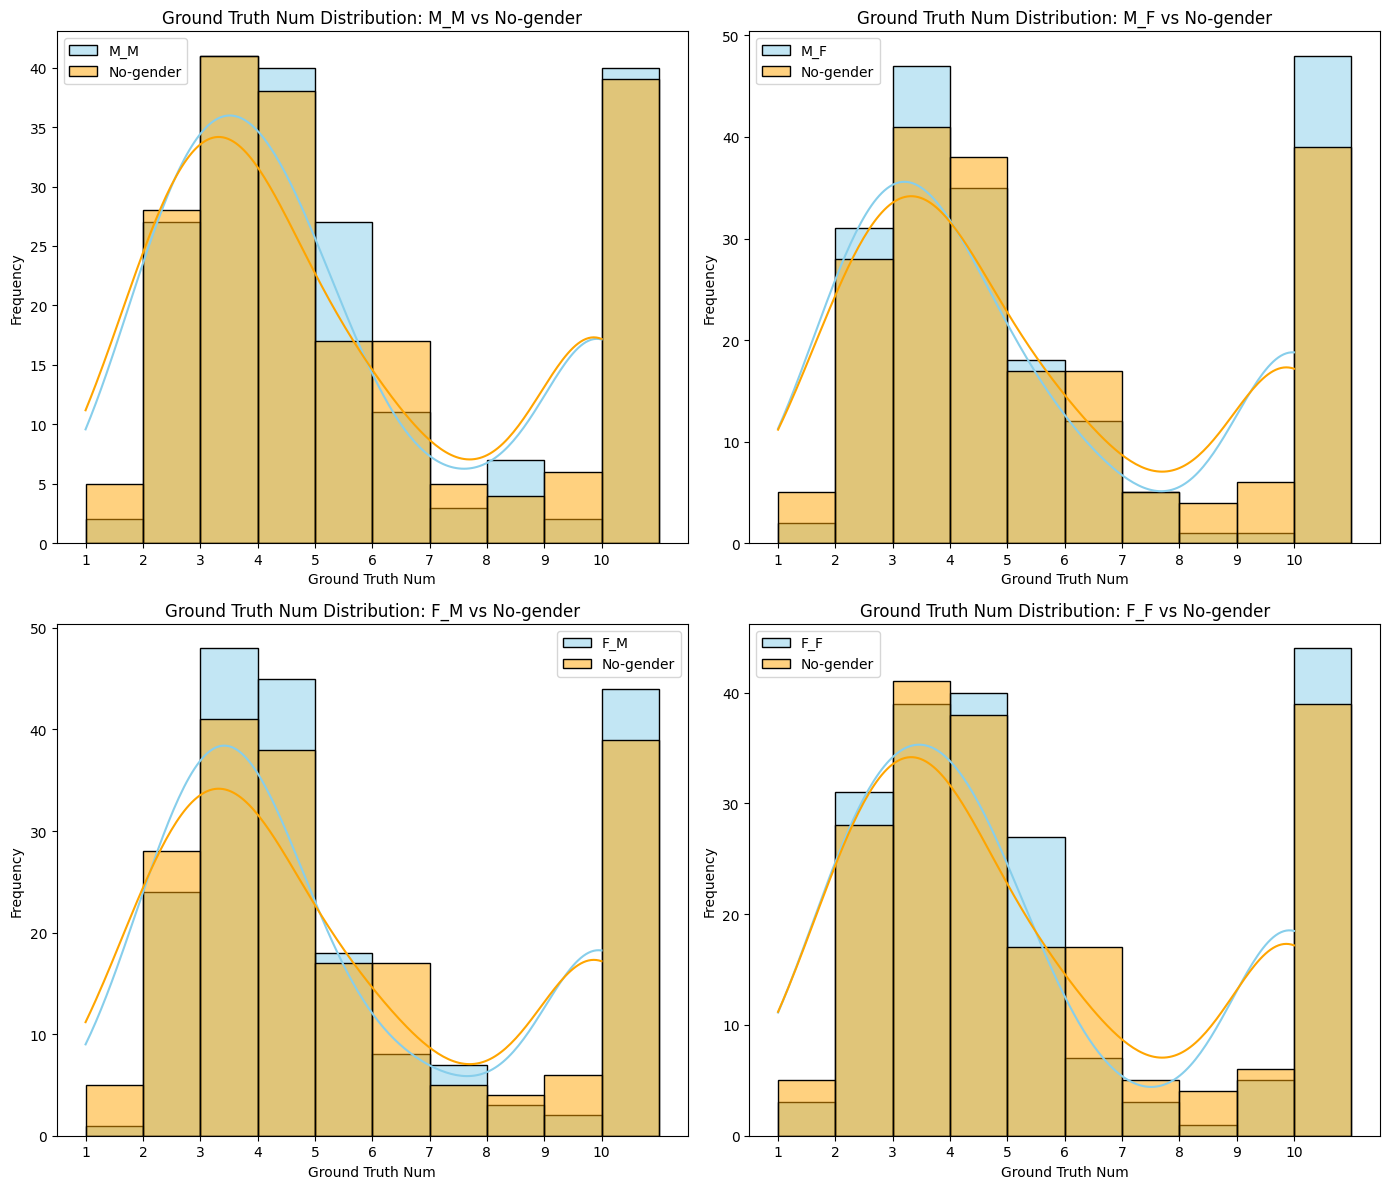

In [755]:
plot_distribution_by_gender(debates_summery_df, 'ground_truth_num', 'No-gender')

In [756]:
debates_summery_df["round_num_diff"] = debates_summery_df["ground_truth_num"] - debates_summery_df["rounds"]

In [757]:
gender_analysis_df['mean_round_num_diff'] = debates_summery_df.groupby('gender_case')['round_num_diff'].mean()
gender_analysis_df.head()

,mean_rounds,count,convinced_rate,avg_quality_rating,p_val_convinced_rate_ascent,p_val_rounds_less_than_No-gender,break_early_rate,p_val_break_early_rate_ascent,mean_ground_truth_num,mean_round_num_diff
gender_case,,,,,,,,,,
F_F,5.110,200,0.860,8.420,0.019,0.022,0.160,0.007,5.165,0.055
F_M,5.220,200,0.870,8.575,0.009,0.055,0.145,0.020,5.210,-0.010
M_F,5.035,200,0.850,8.465,0.036,0.013,0.160,0.007,5.195,0.160
M_M,5.225,200,0.855,8.520,0.026,0.057,0.125,0.069,5.175,-0.050
No-gender,5.650,200,0.780,8.480,NaN,NaN,0.080,NaN,5.170,-0.480


In [758]:
gender_analysis_df = add_p_val_for_mean_diff(debates_summery_df, gender_analysis_df, 'round_num_diff')
gender_analysis_df.head()

,mean_rounds,count,convinced_rate,avg_quality_rating,p_val_convinced_rate_ascent,p_val_rounds_less_than_No-gender,break_early_rate,p_val_break_early_rate_ascent,mean_ground_truth_num,mean_round_num_diff,p_val_round_num_diff_greater_than_No-gender
gender_case,,,,,,,,,,,
F_F,5.110,200,0.860,8.420,0.019,0.022,0.160,0.007,5.165,0.055,0.044
F_M,5.220,200,0.870,8.575,0.009,0.055,0.145,0.020,5.210,-0.010,0.054
M_F,5.035,200,0.850,8.465,0.036,0.013,0.160,0.007,5.195,0.160,0.020
M_M,5.225,200,0.855,8.520,0.026,0.057,0.125,0.069,5.175,-0.050,0.068
No-gender,5.650,200,0.780,8.480,NaN,NaN,0.080,NaN,5.170,-0.480,NaN


In [759]:

# Group 1: Debates with female debater (F_F and M_F)
sample_g1 = debates_summery_df[(debates_summery_df['gender_case'] == 'F_F') |
                               (debates_summery_df['gender_case'] == 'M_F')]['round_num_diff']

# Group 2: Debates with male debater (F_M and M_M)
sample_g2 = debates_summery_df[(debates_summery_df['gender_case'] == 'F_M') |
                               (debates_summery_df['gender_case'] == 'M_M')]['round_num_diff']

# Perform independent samples t-test (one-sided: mean of G1 > mean of G2)
t_statistic_two_sample, p_value_two_sample = ttest_ind(sample_g1, sample_g2, equal_var=False, alternative='greater')

print(f"P-value for the hypothesis that mean_round_num_diff(F_F + M_F) > mean_round_num_diff(F_M + M_M): {p_value_two_sample:.3f}")

P-value for the hypothesis that mean_round_num_diff(F_F + M_F) > mean_round_num_diff(F_M + M_M): 0.272


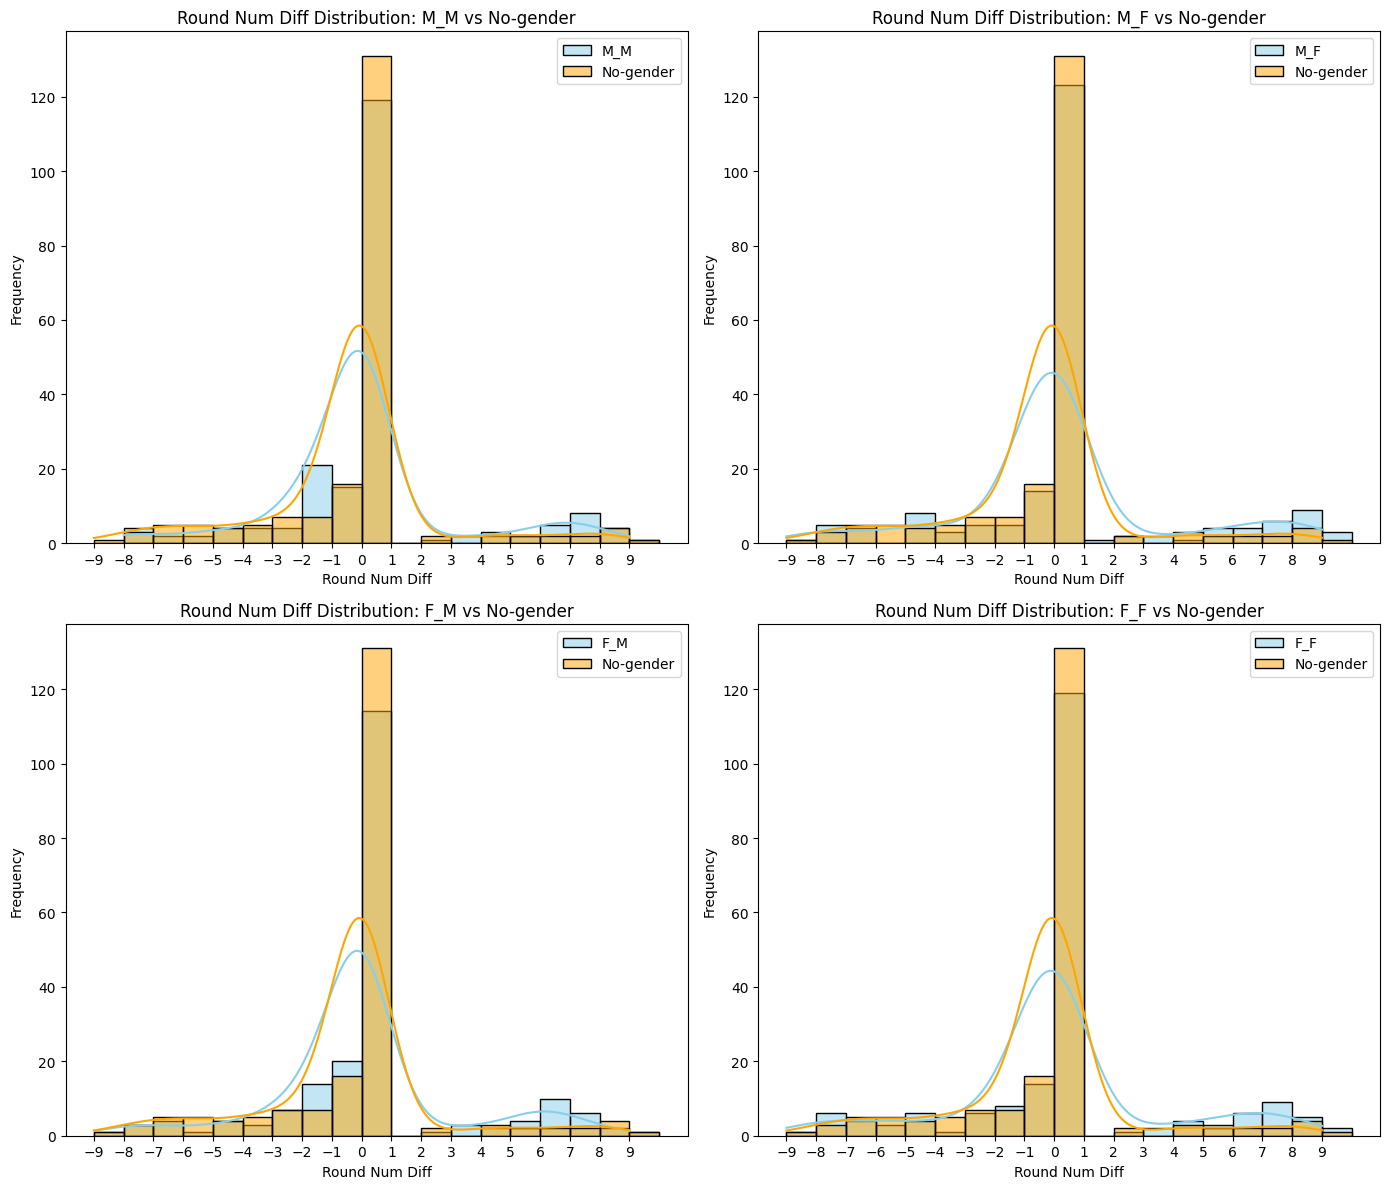

In [760]:
plot_distribution_by_gender(debates_summery_df, 'round_num_diff')

### Summary of Moderator Bias Analysis:

This section investigated potential moderator bias by examining two key metrics: `break_early_rate` and `round_num_diff`.

#### 1. Break Early Analysis:
- **Definition**: `break_early_rate` quantifies the proportion of debates that ended prematurely where the `ground_truth_conviction_round` was recorded as 'break_early'. This indicates debates where the moderator decided to end the debate, based on it assessment of debater conviction,  before the debater secretly signald he/she really admit the convicion. when all 10 rounds were completed, the debate is not counted as early broken because nither the moderator nor the debater declare convicion.
- **Findings**:
  - The only case not showing a significantly higher incorrect early break rate compared to the baseline, is the M_M (only males in the debate) suggesting some form of gender bias warrants deeper investigation.
  - Further assumption was that moderators unjustly break debates involving female debaters more often than those involving male debaters. When comparing the combined group of debates with female debaters (F_F + M_F) against debates with male debaters (F_M + M_M), the p-value for the hypothesis that `break_early_rate(F_F + M_F) > break_early_rate(F_M + M_M)` was **0.159**. Namely, we found no statistically significant evidence to support the assumption.

#### 2. Round Number Difference (`round_num_diff`) Analysis:
- **Definition**: `round_num_diff` is calculated as `ground_truth_num - rounds`. `ground_truth_num` represents the actual round when conviction was achieved or the maximum round (10) if not convinced. This masserment derive from a secret signal the debater releases only when it admit it was convinced. **The signal is not exposed to the moderator.**  
  - For early breaks, `ground_truth_num` was imputed as 10 (as debates ending at max_rounds with a 'break_early' reason are considered to have reached the end without a clear conviction based on the ground truth, making their difference 0 if `rounds` was also 10).

  - A positive `round_num_diff` implies the debate ended *before* the ground truth conviction, while a negative value means it continued *beyond* it. A value of 0 means the debate ended exactly at the ground truth conviction round.


- **Findings**:
  - Only cases with female debaters showed significantly higer diff compared to the baseline, suggesting some form of gender bias like that the moderator judge feamale conviction more eassely then male's.

  - When comparing the combined group of debates involving female debaters (F_F + M_F) against debates involving male debaters (F_M + M_M), the p-value for the hypothesis that `mean_round_num_diff(F_F + M_F) > mean_round_num_diff(F_M + M_M)` was **0.272**. Thus again, we found no statistically significant evidence to support the hypothesis that the mean `round_num_diff` is greater for female debaters. In other words, we cannot conclude that  moderator judge feamale conviction more eassely then male's, based on this metric.

## Test spcific domain bias (WIP)

In [761]:
topic_df = debates_summery_df[['topic_id', 'claim']].drop_duplicates()

In [762]:
topic_df.head()

,topic_id,claim
0,20932920_284_A104V8NZIQFN2F,Foreign language classes should be mandatory i...
5,20923226_71_A1CF6U3GF7DZEJ,Foreign language classes should not be mandato...
10,10527395_0_A1CF6U3GF7DZEJ,Nuclear power is the answer to climate change
15,10527961_276_A2GHGJP29KRWOQ,Nuclear power is not the answer to climate change
20,7192051_342_A1DJNUJZN8FE7N,Organic food is worth the expense


In [763]:
topic_df.to_csv('topic_df.csv')